# MMI 1 X 2 / 2 x 2

## Librerías

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


In [2]:
import importlib
import upvfab_design_tools

importlib.reload(upvfab_design_tools)
from upvfab_design_tools import MMI_EME, DC_EME


In [3]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

## Diseño del MMI 1X2

In [5]:

# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 5.5 # Student. Body width

# m = MMI_EME(VERBOSE=True)  ## --> Para ver el indice efectivo de cada uno de los modos que se propagan 
m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.wg_width_dw = 0.5 # Ancho adicional de la guia para que sea del tamaño del taper
m.MMI_num_modes = 30 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/au/pic-upv-TFM-Paula-Ortiz/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  48.81383142686555  µm


/home/au/pic-upv-TFM-Paula-Ortiz/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


Si tomamos un diseño 2 x 2 la longitud del MMI debe ser de $L_{pi}/2$ mientras que si lo tomamos como un MMI 1 x 2 la longitud será cercana a $\frac{3*L_{pi}}{4*2}$

In [13]:
print("La longitud para un MMI 2 x 2 sería de: ", np.round(L_pi/2,2), "um" )
print("La longitud para un MMI 1 x 2 sería de: ", np.round(3*L_pi/8,2), "um" )

print("La diferencia de longitud es de: ", np.round(L_pi/2-3*L_pi/8,2), "um" )

La longitud para un MMI 2 x 2 sería de:  24.41 um
La longitud para un MMI 1 x 2 sería de:  18.31 um
La diferencia de longitud es de:  6.1 um


La longitud del MMI 1 X 2 es parecida al del diseño de ommatidia 

In [18]:
m.n_IN =  1 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([0]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/4,1/4]) + np.array([-dy, dy]) # STUDENT

m.L_MMI = 3*L_pi/8
# MMI length (check class slides for type of MMI)
#m.dL_MMI = -0.15 # STUDENT

# Run propagation
power, power_total,power_in, phase=m.propagation()


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/366 [00:00<?, ?it/s]

------- Pameters -------
MMI length 18.3052
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 0.9808
Total OUT power: 0.9666
Excess loss [dB] =  0.0632
------------------------
Power over OUTs:  ['0.4833', '0.4833']
Ratio over OUTs ['0.5000', '0.5000']
Phase over OUTs ['79.3582', '79.3575']


## Propagación del MMI 2 X 2 

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/488 [00:00<?, ?it/s]

------- Pameters -------
MMI length 24.4069
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 0.9804
Total OUT power: 0.9438
Excess loss [dB] =  0.1654
------------------------
Power over OUTs:  ['0.4689', '0.4749']
Ratio over OUTs ['0.4968', '0.5032']
Phase over OUTs ['-91.9864', '-177.1788']


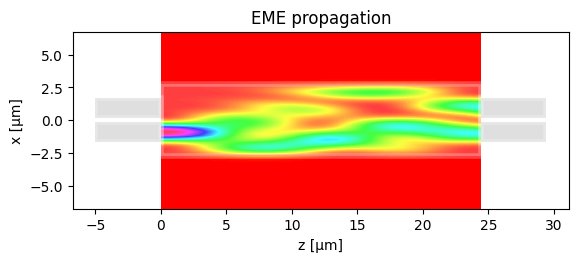

In [9]:
m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6, 1/6]) + np.array([-dy, dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy, dy]) # STUDENT

m.L_MMI = L_pi/2
# MMI length (check class slides for type of MMI)
#m.dL_MMI = -0.15 # STUDENT

# Run propagation
power, power_total,power_in, phase=m.propagation()


## Optimización de parámetros MMI 1 X 2 

se hace la optimización de este diseño, ya que es el que tiene una menor longitud y buscamos tener el diseño más compacto/pequeño posible

1. Se define el MMI 1X2 

In [ ]:

# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 5.5 # Student. Body width

# m = MMI_EME(VERBOSE=True)  ## --> Para ver el indice efectivo de cada uno de los modos que se propagan 
m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.wg_width_dw = 0.5 # Ancho adicional de la guia para que sea del tamaño del taper
m.MMI_num_modes = 30 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/au/pic-upv-TFM-Paula-Ortiz/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  48.81383142685941  µm


/home/au/pic-upv-TFM-Paula-Ortiz/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


2. Se define como van a ser los casos de movimiento de las guías:

Caso 1:

    ------   output 1 -> -1/6 - dy
    ------   output 2 ->  1/6 + dy


    ------   input 1 -> 0 

Caso 2:

    ------   output 1 -> -1/6 - dy2
    ------   output 2 ->  1/6 + dy2


    ------   input 1 -> 0 + dy1



Así, el caso 1 es el siguiente:

In [27]:

m.n_IN =  1 # STUDENT
m.n_OUT = 2 # STUDENT

array_power_out=[]
array_power_in=[]
array_EL=[]
array_DL_MMI=[]
array_power_out1=[]
array_power_out2=[]
array_phase_out1=[]
array_phase_out2=[]
array_phase_o1_o2=[]


for i in range(0,80,5):
    
    # MMI length (check class slides for type of MMI)
    dy = i/100 # STUDENT

    # MMI I/O waveguide positions (check class slides for type of MMI)
    m.IN_WVG_positions = mmi_Width*np.array([0]) # STUDENT
    m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy, dy]) # STUDENT

    m.L_MMI = 3*L_pi/8
    # MMI length (check class slides for type of MMI)
    #m.dL_MMI = -0.15 # STUDENT

    # Run propagation
    power, power_total,power_in, phase=m.propagation()

    #Perdidas
    Loss = 10 * np.log10(power_in / power_total)
    array_EL.append(Loss)

    array_DL_MMI.append(i/100)
    array_power_out1.append((power[0])/power_total)
    array_power_out2.append((power[1])/power_total)

    array_phase_out1.append(phase[0])
    array_phase_out2.append(phase[1])
    array_phase_o1_o2.append(phase[1]-phase[0])

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/366 [00:00<?, ?it/s]

------- Pameters -------
MMI length 18.3052
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 0.9808
Total OUT power: 0.6151
Excess loss [dB] =  2.0263
------------------------
Power over OUTs:  ['0.3076', '0.3075']
Ratio over OUTs ['0.5000', '0.5000']
Phase over OUTs ['79.2244', '79.2226']


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/366 [00:00<?, ?it/s]

...

  0%|          | 0/366 [00:00<?, ?it/s]

------- Pameters -------
MMI length 18.3052
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 0.9808
Total OUT power: 0.9202
Excess loss [dB] =  0.2766
------------------------
Power over OUTs:  ['0.4601', '0.4602']
Ratio over OUTs ['0.4999', '0.5001']
Phase over OUTs ['79.2004', '79.1991']


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/366 [00:00<?, ?it/s]

------- Pameters -------
MMI length 18.3052
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 0.9808
Total OUT power: 0.8879
Excess loss [dB] =  0.4317
------------------------
Power over OUTs:  ['0.4439', '0.4440']
Ratio over OUTs ['0.4999', '0.5001']
Phase over OUTs ['79.1491', '79.1475']


<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_16242/1984674186.py:7: SyntaxWarning: invalid escape sequence '\m'
  axs[0].set_xlabel('dy ($\mu$m)')
/tmp/ipykernel_16242/1984674186.py:17: SyntaxWarning: invalid escape sequence '\m'
  axs[1].set_xlabel('dy ($\mu$m)')


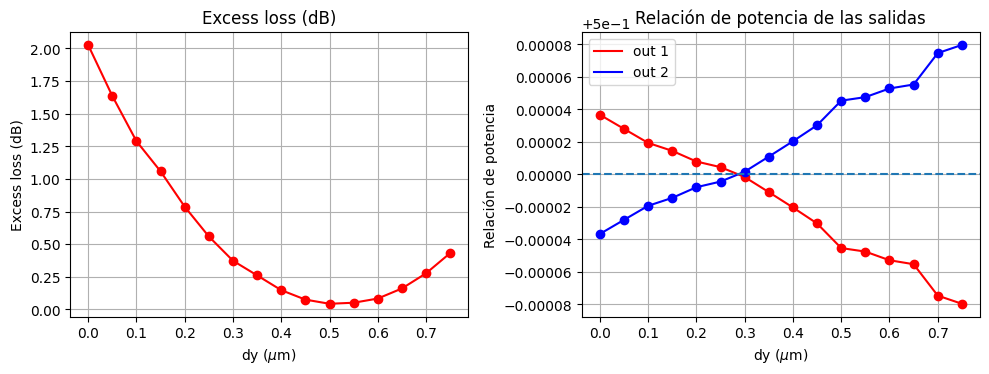

In [34]:

fig, axs = plt.subplots(1, 2, figsize=(10, 4))


axs[0].plot(array_DL_MMI, array_EL, 'r') 
axs[0].plot(array_DL_MMI, array_EL, 'o',linestyle='None',color='r') 
axs[0].set_title('Excess loss (dB)')
axs[0].set_xlabel('dy ($\mu$m)')
axs[0].set_ylabel('Excess loss (dB)')
axs[0].grid(True)

axs[1].plot(array_DL_MMI, array_power_out1, 'r',label='out 1') 
axs[1].plot(array_DL_MMI, array_power_out2, 'b',label='out 2')
axs[1].plot(array_DL_MMI, array_power_out1, 'o',color='r',linestyle='None') 
axs[1].plot(array_DL_MMI, array_power_out2, 'o',color='b',linestyle='None')
axs[1].axhline(y=0.5, linestyle='--', linewidth=1.5)
axs[1].set_title('Relación de potencia de las salidas')
axs[1].set_xlabel('dy ($\mu$m)')
axs[1].set_ylabel('Relación de potencia')
axs[1].legend()
axs[1].grid(True)




plt.tight_layout()

plt.show()

In [39]:

indice_minimo = array_EL.index(min(array_EL))
print('Las menores perdidas son: ', np.round(min(array_EL),3), ". Para un valor de dy = ", array_DL_MMI[indice_minimo] )

Las menores perdidas son:  0.043 . Para un valor de dy =  0.5


En este caso, el mejor resultado da con dy=0.5, pues es el punto de menores, perdidas, es importante resaltar que en el caso de la relación de potencias, el cambio es tan minimo, pues es del orden de decenas micras, por lo que no se ve muy afectada la relación.  

Caso 2:

In [63]:
m.n_IN = 1 
m.n_OUT = 2 


dy2_vals = np.arange(30, 90, 10) / 100  
dy1_vals = np.arange(-10, 10, 2) / 100  


shape_2d = (len(dy2_vals), len(dy1_vals))

Loss_matrix   = np.zeros(shape_2d)
p1_matrix     = np.zeros(shape_2d)
p2_matrix     = np.zeros(shape_2d)
phase1_matrix     = np.zeros(shape_2d)
phase2_matrix     = np.zeros(shape_2d)
diff12_matrix = np.zeros(shape_2d)


for j_idx, j in enumerate(range(30, 90, 10)):
    for i_idx, i in enumerate(range(-10, 10, 2)):

        m.L_MMI = 3*L_pi/8
        dy1 = i/100 
        dy2 = j/100

        m.OUT_WVG_positions = mmi_Width*np.array([-1/6, 1/6]) + np.array([-dy2,dy2]) 
        m.IN_WVG_positions = mmi_Width*np.array([0]) + np.array([dy1]) 
        power, power_total, power_in, phase = m.propagation()
       
        Loss = 10 * np.log10(power_in / power_total)
        Loss_matrix[j_idx, i_idx] = Loss

        p1_matrix[j_idx, i_idx]   = (power[0]) / power_total
        p2_matrix[j_idx, i_idx]   = (power[1]) / power_total
        
        phase1_matrix[j_idx, i_idx] = phase[0]
        phase2_matrix[j_idx, i_idx] = phase[1]

        diff12_matrix[j_idx, i_idx] = phase[1] - phase[0]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/366 [00:00<?, ?it/s]

------- Pameters -------
MMI length 18.3052
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 0.9821
Total OUT power: 0.8912
Excess loss [dB] =  0.4218
------------------------
Power over OUTs:  ['0.4863', '0.4049']
Ratio over OUTs ['0.5457', '0.4543']
Phase over OUTs ['81.5727', '76.9686']


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/366 [00:00<?, ?it/s]

...

  0%|          | 0/366 [00:00<?, ?it/s]

------- Pameters -------
MMI length 18.3052
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 0.9812
Total OUT power: 0.8468
Excess loss [dB] =  0.6398
------------------------
Power over OUTs:  ['0.4263', '0.4205']
Ratio over OUTs ['0.5034', '0.4966']
Phase over OUTs ['77.1723', '81.0221']


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/366 [00:00<?, ?it/s]

------- Pameters -------
MMI length 18.3052
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 0.9817
Total OUT power: 0.8438
Excess loss [dB] =  0.6574
------------------------
Power over OUTs:  ['0.4262', '0.4176']
Ratio over OUTs ['0.5051', '0.4949']
Phase over OUTs ['76.2111', '81.9974']


<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_16242/2813313570.py:41: SyntaxWarning: invalid escape sequence '\m'
  axs[0].set_xlabel('dy1 ($\mu$m)')
/tmp/ipykernel_16242/2813313570.py:49: SyntaxWarning: invalid escape sequence '\m'
  axs[1].set_xlabel('dy1 ($\mu$m)')


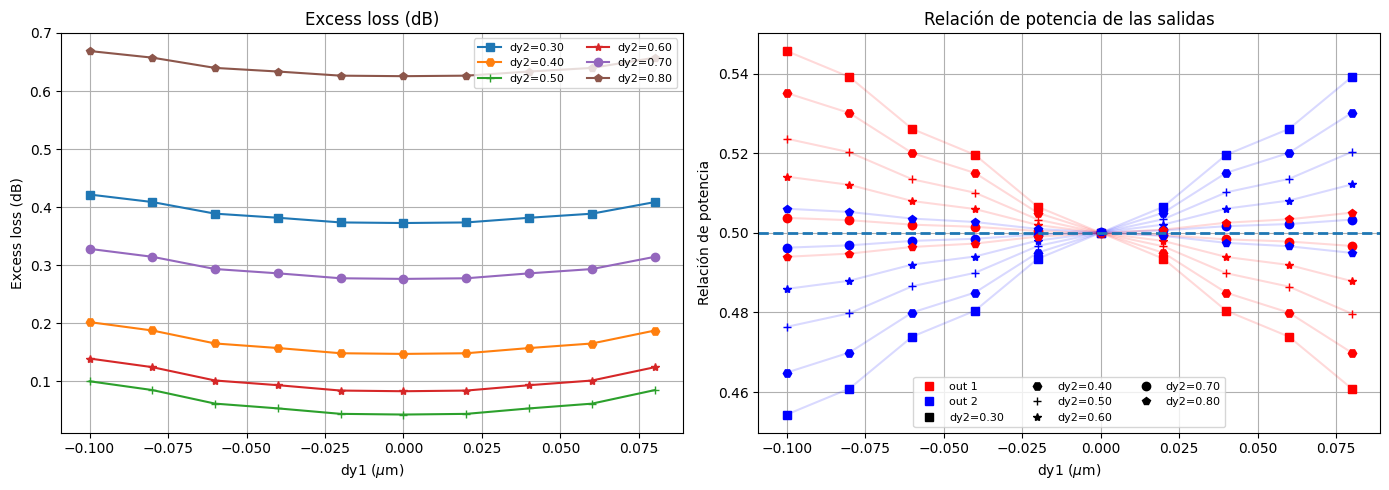

In [ ]:

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

#opacidades = [0.3, 0.5, 0.7, 0.9, 1.0] 
opacidades = [1, 1, 1, 1, 1,1] 
#marcadores = ['s', 'H', '+', '*', 'o','p']
linest=['-','--','-.',':','-']
#linest=['None','None','None','None','None','None']
marcadores = ['s', 'H', '+', '*', 'o', 'p', 'v', '^', '<', '>', 'X'][:len(dy2_vals)]

for j_idx, dy2 in enumerate(dy2_vals):
    lbl_dy2 = f"dy2={dy2:.2f}"
    #alpha = opacidades[j_idx]
    mkr = marcadores[j_idx]
    #ls=linest[j_idx]
    alpha = 0.15
    ls = '-'

    axs[0].plot(dy1_vals, Loss_matrix[j_idx, :], marker=mkr, linestyle='-',label=lbl_dy2)

    if j_idx == 0:
        axs[1].plot(dy1_vals, p1_matrix[j_idx, :], 'r', marker=mkr, alpha=alpha, linestyle=ls )
        axs[1].plot(dy1_vals, p2_matrix[j_idx, :], 'b', marker=mkr, alpha=alpha, linestyle=ls )
        axs[1].plot(dy1_vals, p1_matrix[j_idx, :], 'r', marker=mkr, linestyle='None',label='out 1')
        axs[1].plot(dy1_vals, p2_matrix[j_idx, :], 'b', marker=mkr, linestyle='None',label='out 2')
    else:
        axs[1].plot(dy1_vals, p1_matrix[j_idx, :], 'r', marker=mkr, linestyle=ls , alpha=alpha)
        axs[1].plot(dy1_vals, p2_matrix[j_idx, :], 'b', marker=mkr, linestyle=ls , alpha=alpha)
        axs[1].plot(dy1_vals, p1_matrix[j_idx, :], 'r', marker=mkr, linestyle='None')
        axs[1].plot(dy1_vals, p2_matrix[j_idx, :], 'b', marker=mkr, linestyle='None')
            

    axs[1].plot([], [], color='black', marker=mkr, linestyle='None', label=lbl_dy2)


axs[0].set_title('Excess loss (dB)')
axs[0].set_xlabel('dy1 ($\mu$m)')
axs[0].set_ylabel('Excess loss (dB)')
axs[0].grid(True)
axs[0].legend(fontsize='8', ncol=2)

 
axs[1].axhline(y=0.5, linestyle='--', linewidth=2)
axs[1].set_title('Relación de potencia de las salidas')
axs[1].set_xlabel('dy1 ($\mu$m)')
axs[1].set_ylabel('Relación de potencia')
#axs[1].set_ylim(y_min,y_max)
axs[1].grid(True)
axs[1].legend(fontsize='8', ncol=3) 

plt.tight_layout()
plt.show()

Para este caso, el mejor resultado es cuendo dy1=0 y dy2=0.5, obteniendo el mismo resultado del caso anterior. Por lo que vamos a tomar ese valor de optimización de la posición de entrada/salidas. 

### 2. variación de la longitud del MMI

1. Primero definimos el MMI

In [ ]:

# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 5.5 # Student. Body width

# m = MMI_EME(VERBOSE=True)  ## --> Para ver el indice efectivo de cada uno de los modos que se propagan 
m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.wg_width_dw = 0.5 # Ancho adicional de la guia para que sea del tamaño del taper
m.MMI_num_modes = 30 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

2. Realizamos el barrido de longitudes

In [81]:



m.n_IN =  1 # STUDENT
m.n_OUT = 2 # STUDENT

array_power_out=[]
array_power_in=[]
array_EL=[]
array_DL_MMI=[]
array_power_out1=[]
array_power_out2=[]
array_phase_out1=[]
array_phase_out2=[]
array_phase_o1_o2=[]

dy=0.5

for i in range(-20,20,2):
    
    # MMI length (check class slides for type of MMI)

    m.dL_MMI = i/100 # STUDENT

    # MMI I/O waveguide positions (check class slides for type of MMI)
    m.IN_WVG_positions = mmi_Width*np.array([0]) # STUDENT
    m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy, dy]) # STUDENT

    m.L_MMI = 3*L_pi/8
    # MMI length (check class slides for type of MMI)
    #m.dL_MMI = -0.15 # STUDENT

    # Run propagation
    power, power_total,power_in, phase=m.propagation()

    #Perdidas
    Loss = 10 * np.log10(power_in / power_total)
    array_EL.append(Loss)

    array_DL_MMI.append(i/100)
    array_power_out1.append((power[0])/power_total)
    array_power_out2.append((power[1])/power_total)

    array_phase_out1.append(phase[0])
    array_phase_out2.append(phase[1])
    array_phase_o1_o2.append(phase[1]-phase[0])


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/362 [00:00<?, ?it/s]

------- Pameters -------
MMI length 18.3052
MMI length increment -0.2000
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 0.9808
Total OUT power: 0.9713
Excess loss [dB] =  0.0422
------------------------
Power over OUTs:  ['0.4856', '0.4857']
Ratio over OUTs ['0.5000', '0.5000']
Phase over OUTs ['155.9518', '155.9510']


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/363 [00:00<?, ?it/s]

...

  0%|          | 0/369 [00:00<?, ?it/s]

------- Pameters -------
MMI length 18.3052
MMI length increment 0.1600
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 0.9808
Total OUT power: 0.9695
Excess loss [dB] =  0.0502
------------------------
Power over OUTs:  ['0.4847', '0.4848']
Ratio over OUTs ['0.5000', '0.5000']
Phase over OUTs ['18.0504', '18.0497']


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/370 [00:00<?, ?it/s]

------- Pameters -------
MMI length 18.3052
MMI length increment 0.1800
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 0.9808
Total OUT power: 0.9692
Excess loss [dB] =  0.0515
------------------------
Power over OUTs:  ['0.4846', '0.4846']
Ratio over OUTs ['0.5000', '0.5000']
Phase over OUTs ['10.3890', '10.3882']


<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_16242/224714425.py:7: SyntaxWarning: invalid escape sequence '\m'
  axs[0].set_xlabel('dL ($\mu$m)')
/tmp/ipykernel_16242/224714425.py:17: SyntaxWarning: invalid escape sequence '\m'
  axs[1].set_xlabel('dL ($\mu$m)')


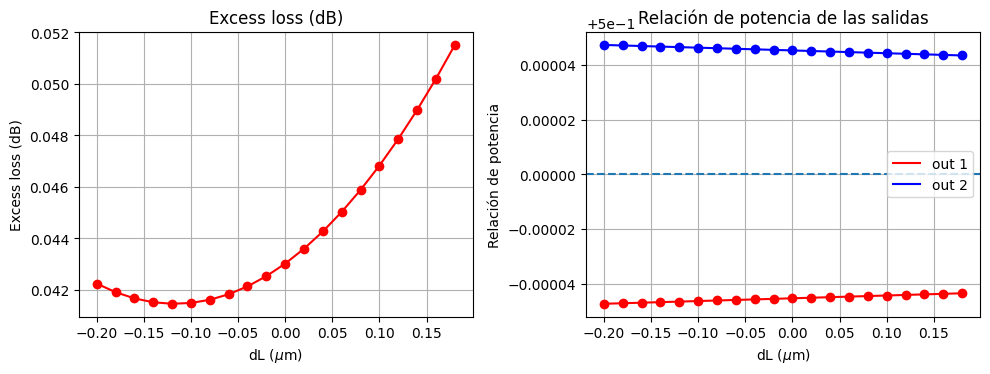

In [82]:

fig, axs = plt.subplots(1, 2, figsize=(10, 4))


axs[0].plot(array_DL_MMI, array_EL, 'r') 
axs[0].plot(array_DL_MMI, array_EL, 'o',linestyle='None',color='r') 
axs[0].set_title('Excess loss (dB)')
axs[0].set_xlabel('dL ($\mu$m)')
axs[0].set_ylabel('Excess loss (dB)')
axs[0].grid(True)

axs[1].plot(array_DL_MMI, array_power_out1, 'r',label='out 1') 
axs[1].plot(array_DL_MMI, array_power_out2, 'b',label='out 2')
axs[1].plot(array_DL_MMI, array_power_out1, 'o',color='r',linestyle='None') 
axs[1].plot(array_DL_MMI, array_power_out2, 'o',color='b',linestyle='None')
axs[1].axhline(y=0.5, linestyle='--', linewidth=1.5)
axs[1].set_title('Relación de potencia de las salidas')
axs[1].set_xlabel('dL ($\mu$m)')
axs[1].set_ylabel('Relación de potencia')
axs[1].legend()
axs[1].grid(True)




plt.tight_layout()

plt.show()

In [83]:

indice_minimo = array_EL.index(min(array_EL))
print('Las menores perdidas son: ', np.round(min(array_EL),3), ". Para un valor de dy = ", array_DL_MMI[indice_minimo] )

Las menores perdidas son:  0.041 . Para un valor de dy =  -0.12


En este caso, tambien se observa que la relación de potencia varia muy poco, así que nos centramos en optimizar el dispositivo a menores perdidas, para este caso se obtienen las menores perdidas en un valor dL = -0.12. De manera que los parámetros de la optimización del MMI 1 X 2 son:


$ dL = -0.12 $                                                   
$ dy_2 = 0.5 $                                            
$ dy_1 = 0 $

Ojo: No hay variación en la posición de la guia de entrada


## Compotamiento del MMI en una ventana de 100 nm:

In [84]:

mmi_Width = 5.5 
L_pi_wvl=[] # array para guardar el L_pi para cada una de las longitudes de onda

array_EL_c2=[]
array_power_out1_c2=[]
array_power_out2_c2=[]
array_phase_out1_c2=[]
array_phase_out2_c2=[]
array_phase_o1_o2_c2=[]


dy2=0.5

wvl_c = (1/1000)*np.linspace(1500, 1600, 10)# STUDENT code goes here

# m = MMI_EME(VERBOSE=True)  
for i in range(0,10,1):
    m = MMI_EME() 
    m.wvl = wvl_c[i]
    m.MMI_width = mmi_Width
    m.wg_width_dw = 0.5 
    m.MMI_num_modes = 30 
                     
    m.find_all_modes()
    L_pi_wvl.append(m.get_L_pi())

    m.n_IN =  1
    m.n_OUT = 2

    m.L_MMI = 3*L_pi/8
    m.dL_MMI = -0.12

    m.OUT_WVG_positions = mmi_Width*np.array([-1/6, 1/6]) + np.array([-dy2,dy2])
    m.IN_WVG_positions = mmi_Width*np.array([0]) 
    power, power_total,power_in, phase=m.propagation()

    #Perdidas
    Loss = 10 * np.log10(power_in / power_total)
    array_EL_c2.append(Loss)


    array_power_out1_c2.append((power[0])/power_total)
    array_power_out2_c2.append((power[1])/power_total)

    array_phase_out1_c2.append(phase[0])
    array_phase_out2_c2.append(phase[1])
    array_phase_o1_o2_c2.append(phase[1]-phase[0])

/home/au/pic-upv-TFM-Paula-Ortiz/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/au/pic-upv-TFM-Paula-Ortiz/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/364 [00:00<?, ?it/s]

------- Pameters -------
MMI length 18.3052
MMI length increment -0.1200
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 0.9791
Total OUT power: 0.9600
Excess loss [dB] =  0.0854
------------------------
Power over OUTs:  ['0.4800', '0.4801']
Ratio over OUTs ['0.4999', '0.5001']
Phase over OUTs ['-148.8946', '-148.8955']


/home/au/pic-upv-TFM-Paula-Ortiz/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/au/pic-upv-TFM-Paula-Ortiz/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


...

------- Pameters -------
MMI length 18.3052
MMI length increment -0.1200
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 0.9820
Total OUT power: 0.9714
Excess loss [dB] =  0.0472
------------------------
Power over OUTs:  ['0.4857', '0.4857']
Ratio over OUTs ['0.5000', '0.5000']
Phase over OUTs ['-34.2693', '-34.2702']


/home/au/pic-upv-TFM-Paula-Ortiz/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/au/pic-upv-TFM-Paula-Ortiz/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/364 [00:00<?, ?it/s]

------- Pameters -------
MMI length 18.3052
MMI length increment -0.1200
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 0.9824
Total OUT power: 0.9702
Excess loss [dB] =  0.0542
------------------------
Power over OUTs:  ['0.4851', '0.4851']
Ratio over OUTs ['0.5000', '0.5000']
Phase over OUTs ['21.0550', '21.0541']


<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_16242/1434528561.py:7: SyntaxWarning: invalid escape sequence '\m'
  axs[0].set_xlabel('Wavelenght ($\mu$m)')
/tmp/ipykernel_16242/1434528561.py:17: SyntaxWarning: invalid escape sequence '\m'
  axs[1].set_xlabel('Wavelenght ($\mu$m)')


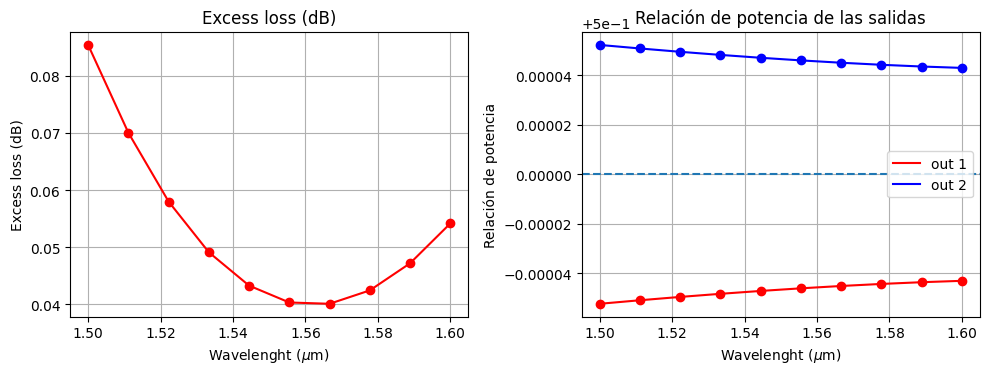

In [86]:

fig, axs = plt.subplots(1, 2, figsize=(10, 4))


axs[0].plot(wvl_c, array_EL_c2, 'r') 
axs[0].plot(wvl_c, array_EL_c2, 'o',linestyle='None',color='r') 
axs[0].set_title('Excess loss (dB)')
axs[0].set_xlabel('Wavelenght ($\mu$m)')
axs[0].set_ylabel('Excess loss (dB)')
axs[0].grid(True)

axs[1].plot(wvl_c, array_power_out1_c2, 'r',label='out 1') 
axs[1].plot(wvl_c, array_power_out2_c2, 'b',label='out 2')
axs[1].plot(wvl_c, array_power_out1_c2, 'o',color='r',linestyle='None') 
axs[1].plot(wvl_c, array_power_out2_c2, 'o',color='b',linestyle='None')
axs[1].axhline(y=0.5, linestyle='--', linewidth=1.5)
axs[1].set_title('Relación de potencia de las salidas')
axs[1].set_xlabel('Wavelenght ($\mu$m)')
axs[1].set_ylabel('Relación de potencia')
axs[1].legend()
axs[1].grid(True)




plt.tight_layout()

plt.show()

In [103]:
indice_max = array_EL_c2.index(max(array_EL_c2))
perdida_pot=10**(-array_EL_c2[indice_max]/10)

print("Las perdidas máximas se dan en la longitud de onda: ", wvl_c[indice_max]*1000, "nm, y son de: ", np.round(array_EL_c2[indice_max],3))
print("En esa longitud de onda se transmitirá el ", np.round(perdida_pot*100,3) , "% de la señal")
print("La diferencia máxima entre las potencias de salida es de: ", np.round((array_power_out2_c2[0]-array_power_out1_c2[0])*1e6,2), "uW")

Las perdidas máximas se dan en la longitud de onda:  1500.0 nm, y son de:  0.085
En esa longitud de onda se transmitirá el  98.052 % de la señal
La diferencia máxima entre las potencias de salida es de:  104.63 uW
